In [ ]:
from ast import literal_eval

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import average_precision_score, roc_auc_score


In [27]:
def signal_features(model, s):
    match model:
        case "Change point":
            return list(range(s))
        case "Interaction":
            return list(range(2*s))
        case "Linear":
            return list(range(s, 2*s))
        case "Mixed":
            return list(range(2*s))
        case _:
            raise ValueError(f"Unknown data model {model}.")

In [ ]:
results = pd.read_csv("results-param_model+2026-07-17+170137.csv")
results = pd.concat((
    results[results['Estimation method'] != 'Causal Forest'],
    pd.read_csv("results-depth=None+2026-07-22+181230.csv"),
), ignore_index=True).replace({
    "LSS confounding": "Change point",
    "Forest DML (econML)": "Forest DML",
})
results['MSE / MSE_0'] = results['MSE'] / results['MSE_0']
results['PEHE / PEHE_0'] = np.sqrt(results['MSE / MSE_0'])
results['Feature importance'] = results['Feature importance'].map(literal_eval).map(np.array)

In [29]:
for i in results.index:
    s = results.loc[i, "s"]
    model = results.loc[i, "model"]
    signal_feat = signal_features(model, s)
    signal_indicator = np.zeros(5*s)
    signal_indicator[signal_feat] = 1
    feat_importance = results.loc[i, 'Feature importance']
    results.loc[i, 'Heterogeneity feature importance'] = feat_importance[signal_feat].sum()
    results.loc[i, 'ROC-AUC'] = roc_auc_score(signal_indicator, feat_importance)
    results.loc[i, 'avg precision'] = average_precision_score(signal_indicator, feat_importance)

In [30]:
results  # [(results['s'] == 1) & (results['model'] == "Linear")]

,s,iter,model,Estimation method,MSE,MSE_0,Feature importance,MSE / MSE_0,PEHE / PEHE_0,Heterogeneity feature importance,ROC-AUC,avg precision
0,1,3,Interaction,IntCF,0.045693,0.254735,"[0.3345501632644262, 0.34489393826968046, 0.08...",0.179374,0.423525,0.679444,1.000000,1.000000
1,1,3,Change point,IntCF,0.071108,0.790449,"[0.5868775148835391, 0.09565310140796786, 0.08...",0.089958,0.299931,0.586878,1.000000,1.000000
2,1,3,Linear,IntCF,0.029281,0.148717,"[0.12939482405057642, 0.5113264697851864, 0.11...",0.196889,0.443722,0.511326,1.000000,1.000000
3,1,3,Mixed,IntCF,0.076241,0.271781,"[0.34605484743783416, 0.24291255834999315, 0.1...",0.280524,0.529645,0.588967,1.000000,1.000000
4,1,5,Interaction,IntCF,0.051986,0.249897,"[0.3183247239576695, 0.28931409108315964, 0.11...",0.208028,0.456101,0.607639,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
4795,10,17,Mixed,Causal Forest,2.333063,2.471418,"[0.018296381713816354, 0.012149797547380112, 0...",0.944018,0.971606,0.272988,0.325000,0.314507
4796,10,7,Interaction,Causal Forest,2.023598,2.501304,"[0.021122845752198586, 0.02417285389426678, 0....",0.809017,0.899454,0.497098,0.938333,0.932794
4797,10,7,Change point,Causal Forest,1.945898,2.828546,"[0.029717596689616977, 0.027276714557383955, 0...",0.687950,0.829427,0.335717,0.980000,0.941389
4798,10,7,Linear,Causal Forest,0.693902,0.856492,"[0.024482763080823262, 0.05687418400222617, 0....",0.810168,0.900093,0.230590,0.780000,0.360741


## Output formatting

In [42]:
output_format = r"{mean:.3f} ± {se:.3f}"
model_order = ['Interaction', 'Change point', 'Linear', 'Mixed']
method_order = ['IntCF', 'Forest DML', 'Causal Forest', 'GRF']
plot_order = [[0, 0], [0, 1], [1, 0], [1, 1]]
mpl.rcParams['font.family'] = 'Frutiger Next LT W1G'
sns.set_context("paper")
figsize = (8, 6)
# sns.set_context("poster")
# figsize = (16, 12)

## Combined plots

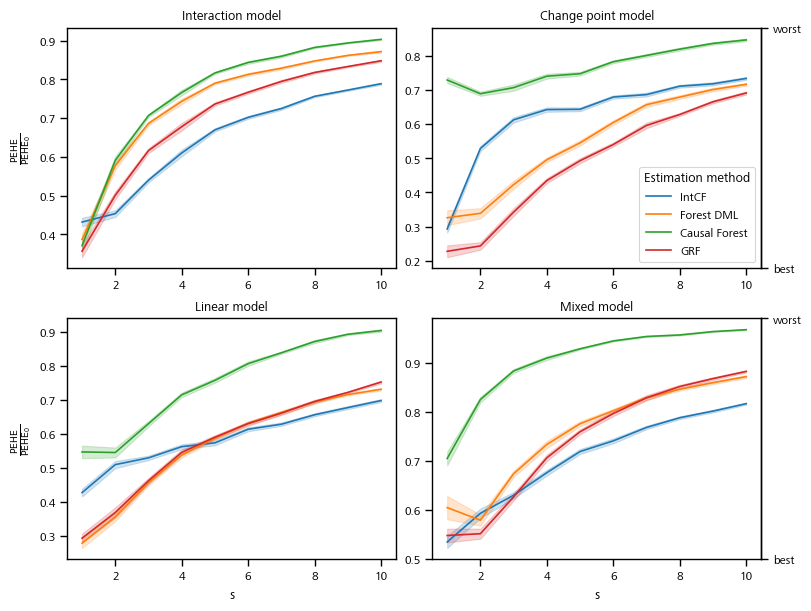

In [43]:
fig, axs = plt.subplots(2, 2, figsize=figsize, layout='constrained')

for model, pos in zip(model_order, plot_order):
    ax = axs[pos[0], pos[1]]
    filtered = results[results['model'] == model]
    sns.lineplot(
        filtered, x='s', y='PEHE / PEHE_0', errorbar='se',
        hue='Estimation method', hue_order=method_order,
        ax=ax, legend=(pos==[0, 1])
    )
    if pos[0] == 0:
        ax.set_xlabel(None)
    if pos[1] == 0:
        ax.set_ylabel(r"$\frac{\operatorname{PEHE}}{\operatorname{PEHE}_0}$")
    else:
        ax.set_ylabel(None)
        sec_ax = ax.secondary_yaxis('right')
        sec_ax.set_yticks(ax.get_ylim(), ["best", "worst"])
    ax.set_title(model + " model")

plt.savefig("img/paper-pehe.png", bbox_inches='tight')

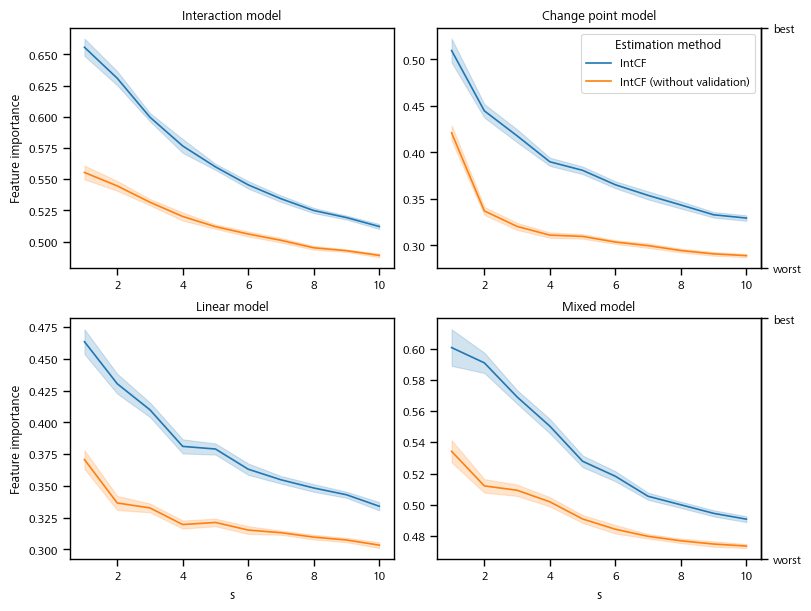

In [44]:
fig, axs = plt.subplots(2, 2, figsize=figsize, layout='constrained')

for model, pos in zip(model_order, plot_order):
    ax = axs[pos[0], pos[1]]
    filtered = results[results['model'] == model]
    sns.lineplot(
        filtered, x='s', y='Heterogeneity feature importance', errorbar='se',
        hue='Estimation method', hue_order=["IntCF", "IntCF (without validation)"],
        ax=ax, legend=(pos==[0, 1])
    )
    if pos[0] == 0:
        ax.set_xlabel(None)
    if pos[1] == 0:
        ax.set_ylabel("Feature importance")
    else:
        ax.set_ylabel(None)
        sec_ax = ax.secondary_yaxis('right')
        sec_ax.set_yticks(ax.get_ylim(), ["worst", "best"])
    ax.set_title(model + " model")

plt.savefig("img/intcf-feat_importance.png", bbox_inches='tight')

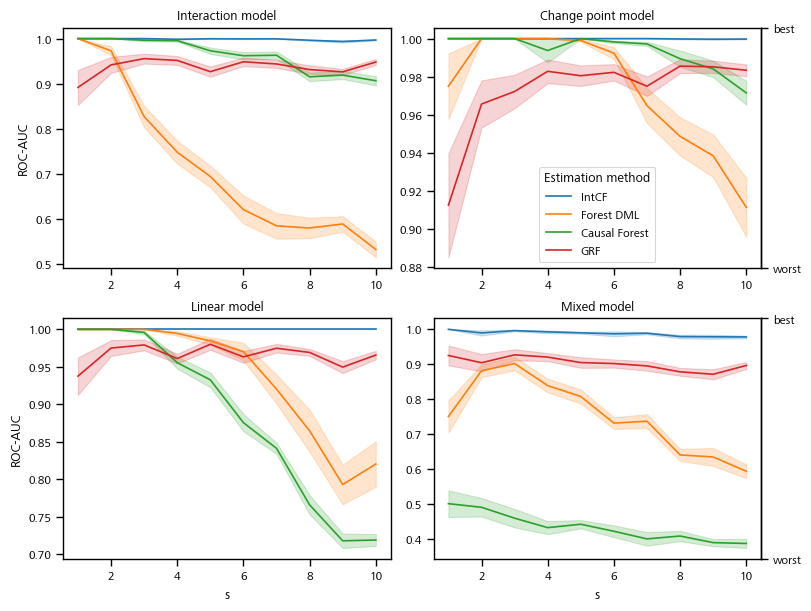

In [45]:
fig, axs = plt.subplots(2, 2, figsize=figsize, layout='constrained')

for model, pos in zip(model_order, plot_order):
    ax = axs[pos[0], pos[1]]
    filtered = results[results['model'] == model]
    sns.lineplot(
        filtered, x='s', y='ROC-AUC', errorbar='se',
        hue='Estimation method', hue_order=method_order,
        ax=ax, legend=(pos==[0, 1])
    )
    if pos[0] == 0:
        ax.set_xlabel(None)
    if pos[1] == 0:
        ax.set_ylabel("ROC-AUC")
    else:
        ax.set_ylabel(None)
        sec_ax = ax.secondary_yaxis('right')
        sec_ax.set_yticks(ax.get_ylim(), ["worst", "best"])
    ax.set_title(model + " model")

plt.savefig("img/paper-roc_auc.png", bbox_inches='tight')

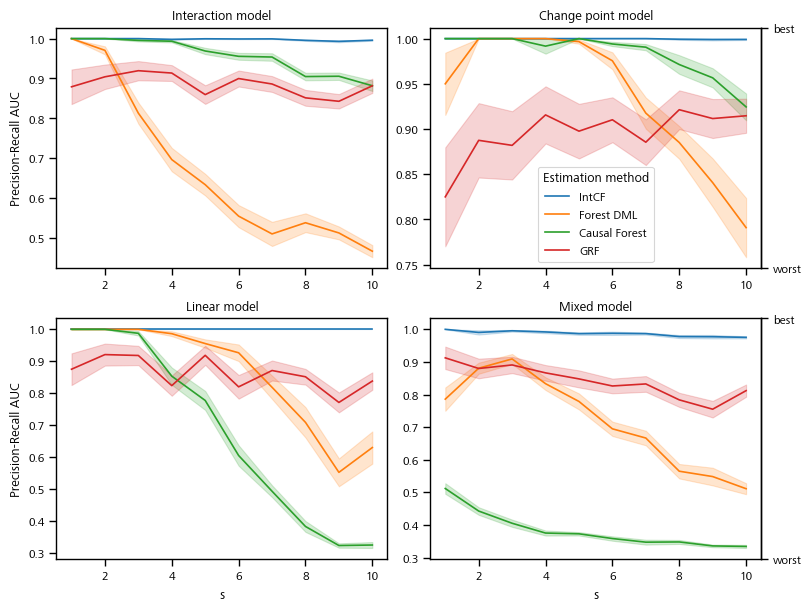

In [46]:
fig, axs = plt.subplots(2, 2, figsize=figsize, layout='constrained')

for model, pos in zip(model_order, plot_order):
    ax = axs[pos[0], pos[1]]
    filtered = results[results['model'] == model]
    sns.lineplot(
        filtered, x='s', y='avg precision', errorbar='se',
        hue='Estimation method', hue_order=method_order,
        ax=ax, legend=(pos==[0, 1])
    )
    if pos[0] == 0:
        ax.set_xlabel(None)
    if pos[1] == 0:
        ax.set_ylabel("Precision-Recall AUC")
    else:
        ax.set_ylabel(None)
        sec_ax = ax.secondary_yaxis('right')
        sec_ax.set_yticks(ax.get_ylim(), ["worst", "best"])
    ax.set_title(model + " model")

# plt.savefig("img/all-precision_recall.png", bbox_inches='tight')

## Graphs for appendix

In [47]:
method_order = ['IntCF', 'Forest DML', 'Causal Forest', 'GRF', 'IntCF (without validation)']

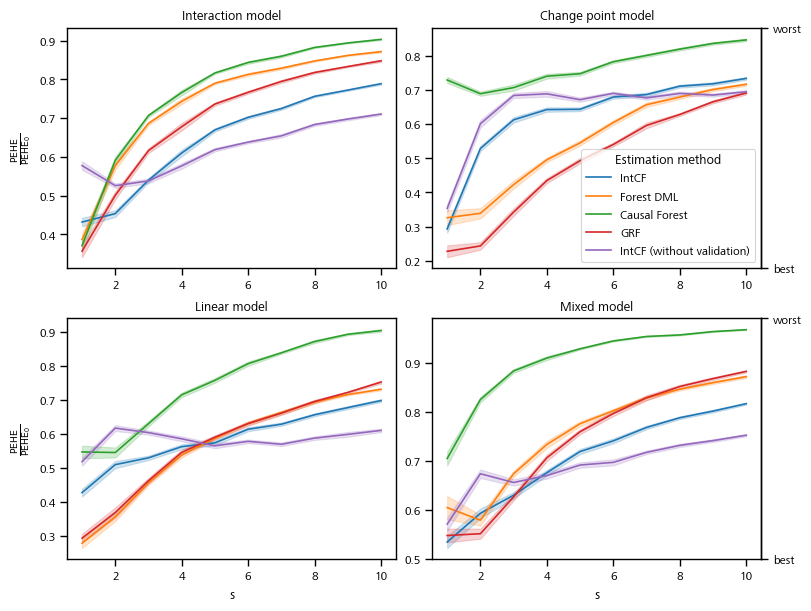

In [48]:
fig, axs = plt.subplots(2, 2, figsize=figsize, layout='constrained')

for model, pos in zip(model_order, plot_order):
    ax = axs[pos[0], pos[1]]
    filtered = results[results['model'] == model]
    sns.lineplot(
        filtered, x='s', y='PEHE / PEHE_0', errorbar='se',
        hue='Estimation method', hue_order=method_order,
        ax=ax, legend=(pos==[0, 1])
    )
    if pos[0] == 0:
        ax.set_xlabel(None)
    if pos[1] == 0:
        ax.set_ylabel(r"$\frac{\operatorname{PEHE}}{\operatorname{PEHE}_0}$")
    else:
        ax.set_ylabel(None)
        sec_ax = ax.secondary_yaxis('right')
        sec_ax.set_yticks(ax.get_ylim(), ["best", "worst"])
    ax.set_title(model + " model")

plt.savefig("img/all-pehe.png", bbox_inches='tight')

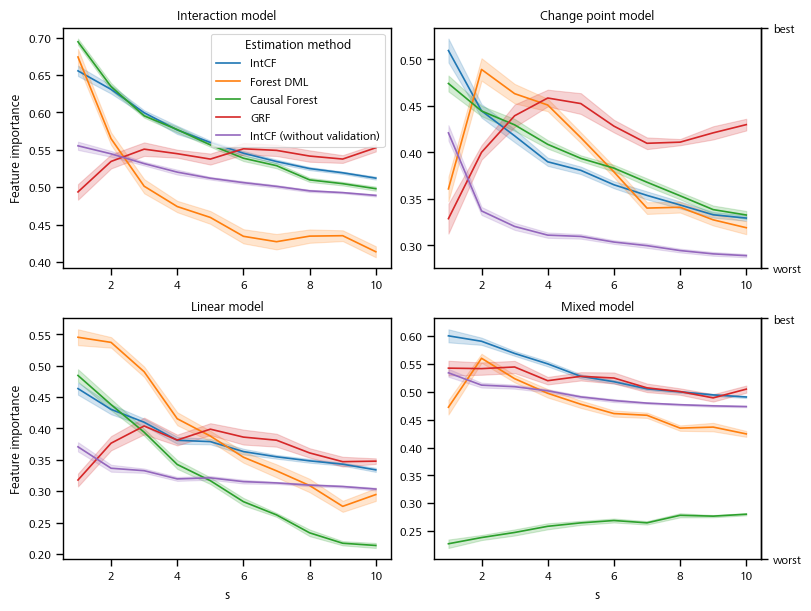

In [51]:
fig, axs = plt.subplots(2, 2, figsize=figsize, layout='constrained')

for model, pos in zip(model_order, plot_order):
    ax = axs[pos[0], pos[1]]
    filtered = results[results['model'] == model]
    sns.lineplot(
        filtered, x='s', y='Heterogeneity feature importance', errorbar='se',
        hue='Estimation method', hue_order=method_order,
        ax=ax, legend=(pos==[0, 0])
    )
    if pos[0] == 0:
        ax.set_xlabel(None)
    if pos[1] == 0:
        ax.set_ylabel("Feature importance")
    else:
        ax.set_ylabel(None)
        sec_ax = ax.secondary_yaxis('right')
        sec_ax.set_yticks(ax.get_ylim(), ["worst", "best"])
    ax.set_title(model + " model")

plt.savefig("img/all-feat_importance.png", bbox_inches='tight')

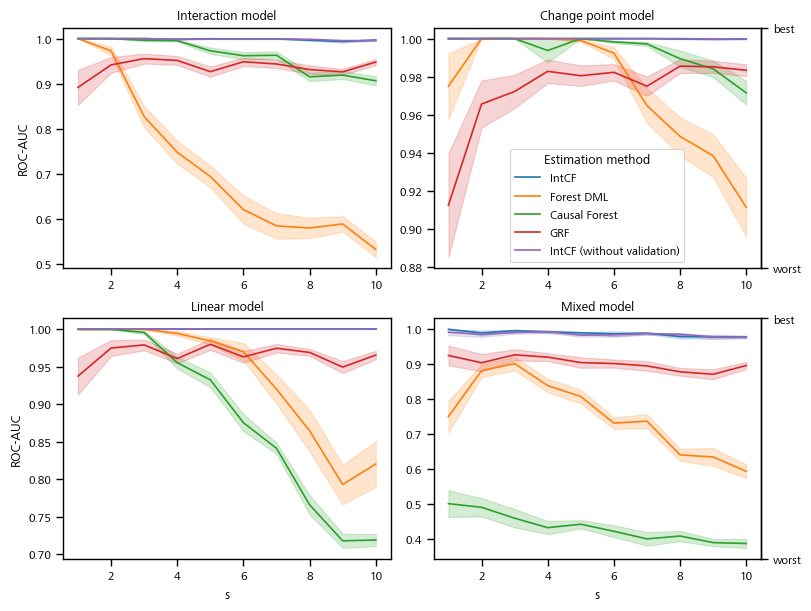

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=figsize, layout='constrained')

for model, pos in zip(model_order, plot_order):
    ax = axs[pos[0], pos[1]]
    filtered = results[results['model'] == model]
    sns.lineplot(
        filtered, x='s', y='ROC-AUC', errorbar='se',
        hue='Estimation method', hue_order=method_order,
        ax=ax, legend=(pos==[0, 1])
    )
    if pos[0] == 0:
        ax.set_xlabel(None)
    if pos[1] == 0:
        ax.set_ylabel("ROC-AUC")
    else:
        ax.set_ylabel(None)
        sec_ax = ax.secondary_yaxis('right')
        sec_ax.set_yticks(ax.get_ylim(), ["worst", "best"])
    ax.set_title(model + " model")

plt.savefig("img/all-roc_auc.png", bbox_inches='tight')

## Tables with all results

In [52]:
outputs_mean = results.groupby(by=['model', 's', 'Estimation method']).mean(numeric_only=True)
outputs_se = results.groupby(by=['model', 's', 'Estimation method']).sem(numeric_only=True)

In [56]:
metric = 'ROC-AUC'  # 'PEHE / PEHE_0', 'Heterogeneity feature importance', 'ROC-AUC', 'avg precision'
table = outputs_mean[metric].combine(outputs_se[metric], lambda mean, se: output_format.format(mean=mean, se=se)).reset_index().pivot(index=['model', 's'], columns='Estimation method', values=metric).loc[model_order, method_order]
print(table.reset_index().to_latex(index=False))

\begin{tabular}{lrlllll}
\toprule
model & s & IntCF & Forest DML & Causal Forest & GRF & IntCF (without validation) \\
\midrule
Interaction & 1 & 1.000 ± 0.000 & 1.000 ± 0.000 & 1.000 ± 0.000 & 0.892 ± 0.039 & 1.000 ± 0.000 \\
Interaction & 2 & 1.000 ± 0.000 & 0.973 ± 0.010 & 1.000 ± 0.000 & 0.942 ± 0.018 & 1.000 ± 0.000 \\
Interaction & 3 & 1.000 ± 0.000 & 0.827 ± 0.024 & 0.996 ± 0.002 & 0.956 ± 0.011 & 1.000 ± 0.000 \\
Interaction & 4 & 0.998 ± 0.001 & 0.748 ± 0.025 & 0.995 ± 0.002 & 0.952 ± 0.010 & 0.998 ± 0.001 \\
Interaction & 5 & 1.000 ± 0.000 & 0.694 ± 0.024 & 0.973 ± 0.007 & 0.927 ± 0.011 & 0.999 ± 0.000 \\
Interaction & 6 & 0.999 ± 0.001 & 0.621 ± 0.031 & 0.962 ± 0.008 & 0.949 ± 0.009 & 0.999 ± 0.000 \\
Interaction & 7 & 0.999 ± 0.000 & 0.585 ± 0.028 & 0.963 ± 0.008 & 0.944 ± 0.009 & 0.999 ± 0.000 \\
Interaction & 8 & 0.996 ± 0.001 & 0.580 ± 0.023 & 0.915 ± 0.010 & 0.931 ± 0.009 & 0.998 ± 0.001 \\
Interaction & 9 & 0.994 ± 0.002 & 0.589 ± 0.017 & 0.919 ± 0.009 & 0.926 ± 0.007 

In [54]:
table

Estimation method          IntCF     Forest DML  Causal Forest            GRF  \
model        s                                                                  
Interaction  1     0.432 ± 0.011  0.387 ± 0.015  0.371 ± 0.017  0.357 ± 0.016   
             2     0.454 ± 0.009  0.577 ± 0.010  0.591 ± 0.010  0.501 ± 0.010   
             3     0.540 ± 0.006  0.686 ± 0.004  0.707 ± 0.004  0.616 ± 0.006   
             4     0.610 ± 0.009  0.743 ± 0.007  0.766 ± 0.007  0.678 ± 0.010   
             5     0.670 ± 0.004  0.790 ± 0.003  0.817 ± 0.002  0.736 ± 0.004   
             6     0.702 ± 0.004  0.813 ± 0.003  0.844 ± 0.003  0.767 ± 0.004   
             7     0.725 ± 0.003  0.829 ± 0.003  0.860 ± 0.003  0.795 ± 0.004   
             8     0.756 ± 0.002  0.848 ± 0.002  0.882 ± 0.002  0.818 ± 0.003   
             9     0.773 ± 0.002  0.862 ± 0.002  0.894 ± 0.001  0.833 ± 0.002   
             10    0.789 ± 0.003  0.872 ± 0.002  0.903 ± 0.002  0.848 ± 0.003   
Change point 1     0.293 ± 0.011  0.326 ± 0.022  0.730 ± 0.009  0.227 ± 0.017   
             2     0.529 ± 0.008  0.339 ± 0.015  0.689 ± 0.006  0.243 ± 0.011   
             3     0.613 ± 0.008  0.423 ± 0.012  0.707 ± 0.009  0.342 ± 0.011   
             4     0.643 ± 0.007  0.496 ± 0.007  0.741 ± 0.007  0.435 ± 0.007   
             5     0.644 ± 0.006  0.545 ± 0.008  0.748 ± 0.005  0.493 ± 0.008   
             6     0.680 ± 0.005  0.605 ± 0.007  0.783 ± 0.004  0.541 ± 0.006   
             7     0.687 ± 0.006  0.657 ± 0.006  0.802 ± 0.004  0.596 ± 0.008   
             8     0.712 ± 0.004  0.680 ± 0.006  0.820 ± 0.004  0.629 ± 0.004   
             9     0.718 ± 0.005  0.702 ± 0.005  0.837 ± 0.004  0.666 ± 0.004   
             10    0.734 ± 0.004  0.717 ± 0.004  0.847 ± 0.004  0.692 ± 0.005   
Linear       1     0.427 ± 0.011  0.279 ± 0.014  0.547 ± 0.018  0.293 ± 0.013   
             2     0.509 ± 0.011  0.356 ± 0.013  0.545 ± 0.015  0.369 ± 0.015   
             3     0.529 ± 0.006  0.456 ± 0.007  0.630 ± 0.008  0.462 ± 0.008   
             4     0.562 ± 0.007  0.538 ± 0.007  0.714 ± 0.007  0.545 ± 0.008   
             5     0.573 ± 0.007  0.587 ± 0.004  0.757 ± 0.007  0.590 ± 0.006   
             6     0.613 ± 0.006  0.631 ± 0.005  0.806 ± 0.006  0.630 ± 0.006   
             7     0.628 ± 0.005  0.662 ± 0.006  0.838 ± 0.003  0.661 ± 0.005   
             8     0.656 ± 0.004  0.693 ± 0.004  0.871 ± 0.005  0.695 ± 0.005   
             9     0.677 ± 0.004  0.715 ± 0.002  0.892 ± 0.003  0.722 ± 0.003   
             10    0.698 ± 0.004  0.731 ± 0.003  0.903 ± 0.004  0.752 ± 0.004   
Mixed        1     0.534 ± 0.012  0.604 ± 0.024  0.705 ± 0.014  0.547 ± 0.014   
             2     0.593 ± 0.010  0.578 ± 0.011  0.825 ± 0.006  0.551 ± 0.010   
             3     0.629 ± 0.007  0.673 ± 0.006  0.884 ± 0.004  0.626 ± 0.007   
             4     0.675 ± 0.006  0.733 ± 0.007  0.910 ± 0.004  0.706 ± 0.007   
             5     0.719 ± 0.005  0.776 ± 0.005  0.929 ± 0.002  0.759 ± 0.005   
             6     0.741 ± 0.005  0.802 ± 0.004  0.945 ± 0.001  0.796 ± 0.005   
             7     0.768 ± 0.004  0.828 ± 0.004  0.954 ± 0.001  0.829 ± 0.005   
             8     0.788 ± 0.003  0.846 ± 0.003  0.957 ± 0.001  0.852 ± 0.004   
             9     0.801 ± 0.003  0.860 ± 0.003  0.964 ± 0.001  0.868 ± 0.003   
             10    0.817 ± 0.002  0.872 ± 0.003  0.968 ± 0.001  0.883 ± 0.002   

Estimation method IntCF (without validation)  
model        s                                
Interaction  1                 0.578 ± 0.011  
             2                 0.526 ± 0.006  
             3                 0.538 ± 0.006  
             4                 0.577 ± 0.007  
             5                 0.619 ± 0.005  
             6                 0.638 ± 0.003  
             7                 0.654 ± 0.004  
             8                 0.684 ± 0.003  
             9                 0.698 ± 0.003  
             10                0.711 ± 0.003  
Change point 1                 0.